# **1. Perkenalan Dataset**


## Eksperimen Machine Learning — Titanic: ML from Disaster

**Nama:** Fauzan Aidil Luthfi

**NIM:** APC352D6Y0439


**Dataset:** Titanic — ML from Disaster (Kaggle Competition)  
**Sumber:** https://www.kaggle.com/competitions/tfugp-titanic-ml-from-disaster/data  
**Tujuan/Hasil Akhir:** Memprediksi apakah seorang penumpang selamat (Survived=1) atau tidak (Survived=0)  

---



# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Konfigurasi tampilan
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('library Source Complete')
print(f'Pandas   : {pd.__version__}')
print(f'NumPy    : {np.__version__}')

library Source Complete
Pandas   : 2.2.3
NumPy    : 2.1.3


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [30]:
df = pd.read_csv(r'C:\Users\OJAN\Pictures\SMSML_Fauzan Aidil\train.csv')
print(f'Dataset Titanic berhasil dimuat!')
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'\nPreview 5 baris pertama:')
df.head()

Dataset Titanic berhasil dimuat!
Jumlah baris   : 891
Jumlah kolom   : 12

Preview 5 baris pertama:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
# Simpan salinan data asli
df_raw = df.copy()

print('=== PENJELASAN KOLOM DATASET TITANIC ===')
print('''
PassengerId : Nomor unik untuk tiap penumpang
Survived    : Label/target — apakah penumpang selamat (1 = selamat, 0 = tidak)
Pclass      : Kelas tiket penumpang (1 = kelas atas, 2 = menengah, 3 = ekonomi)
Name        : Nama lengkap penumpang (biasanya ada gelar seperti Mr, Mrs, Miss, dll)
Sex         : Jenis kelamin penumpang (male / female)
Age         : Umur penumpang (tipe float, ada cukup banyak data kosong sekitar 19%)
SibSp       : Jumlah saudara kandung atau pasangan yang ikut di kapal
Parch       : Jumlah orang tua atau anak yang ikut di kapal
Ticket      : Nomor tiket (umumnya tidak digunakan dalam analisis/model)
Fare        : Harga tiket yang dibayar penumpang
Cabin       : Nomor kabin (banyak data kosong, sekitar 77%)
Embarked    : Pelabuhan keberangkatan
              (C = Cherbourg, Q = Queenstown, S = Southampton)
''')

=== PENJELASAN KOLOM DATASET TITANIC ===

PassengerId : Nomor unik untuk tiap penumpang
Survived    : Label/target — apakah penumpang selamat (1 = selamat, 0 = tidak)
Pclass      : Kelas tiket penumpang (1 = kelas atas, 2 = menengah, 3 = ekonomi)
Name        : Nama lengkap penumpang (biasanya ada gelar seperti Mr, Mrs, Miss, dll)
Sex         : Jenis kelamin penumpang (male / female)
Age         : Umur penumpang (tipe float, ada cukup banyak data kosong sekitar 19%)
SibSp       : Jumlah saudara kandung atau pasangan yang ikut di kapal
Parch       : Jumlah orang tua atau anak yang ikut di kapal
Ticket      : Nomor tiket (umumnya tidak digunakan dalam analisis/model)
Fare        : Harga tiket yang dibayar penumpang
Cabin       : Nomor kabin (banyak data kosong, sekitar 77%)
Embarked    : Pelabuhan keberangkatan
              (C = Cherbourg, Q = Queenstown, S = Southampton)



# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [35]:
## informasi dataset
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [36]:
## Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe().round(3)

=== STATISTIK DESKRIPTIF ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000,891.000,891.000,714.000,891.000,891.000,891.000
mean,446.000,0.384,2.309,29.699,0.523,0.382,32.204
std,257.354,0.487,0.836,14.526,1.103,0.806,49.693
min,1.000,0.000,1.000,0.420,0.000,0.000,0.000
25%,223.500,0.000,2.000,20.125,0.000,0.000,7.910
50%,446.000,0.000,3.000,28.000,0.000,0.000,14.454
75%,668.500,1.000,3.000,38.000,1.000,0.000,31.000
max,891.000,1.000,3.000,80.000,8.000,6.000,512.329


=== MISSING VALUES ===
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


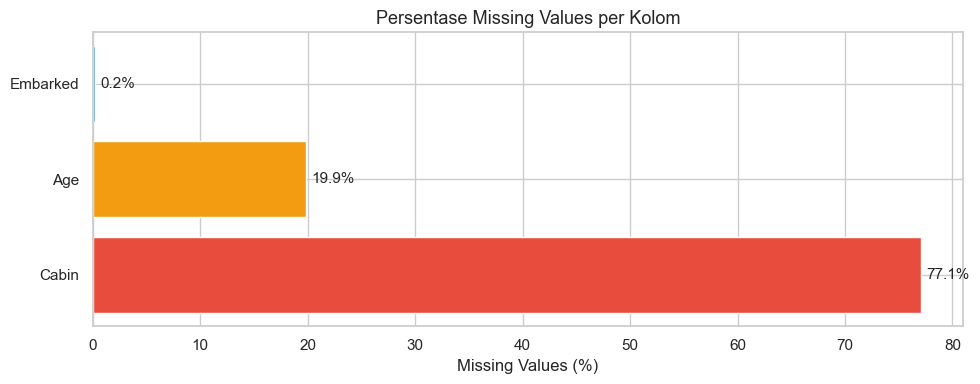

In [34]:
# Analisis Missing Values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
bars = ax.barh(cols_with_missing.index, cols_with_missing['Missing %'],
               color=['#e74c3c','#f39c12','#3498db'])
ax.set_xlabel('Missing Values (%)')
ax.set_title('Persentase Missing Values per Kolom', fontsize=13)
for bar, val in zip(bars, cols_with_missing['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Cek duplikat
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

Jumlah baris duplikat: 0


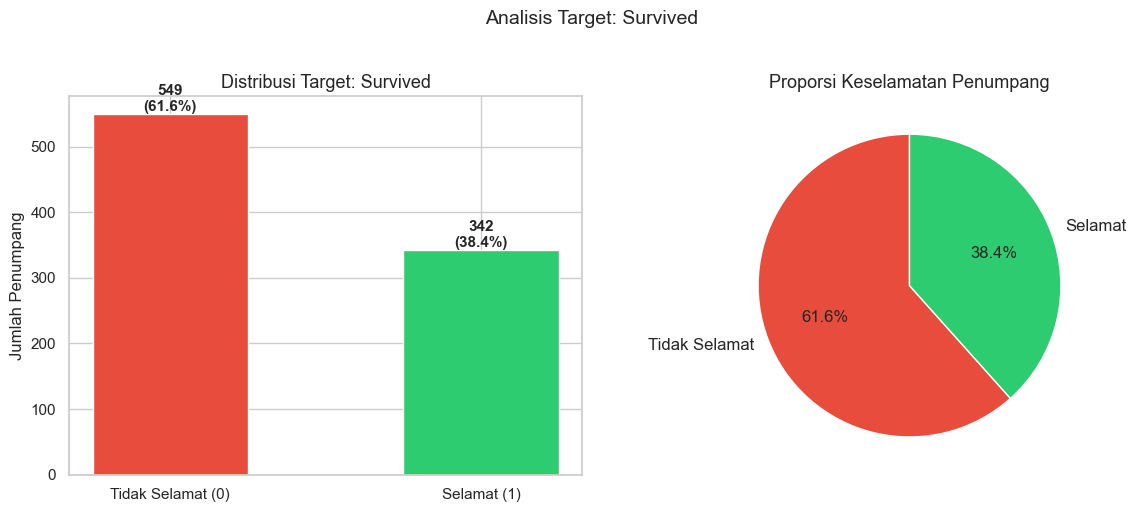

Selamat     : 342 (38.4%)
Tidak selamat: 549 (61.6%)


In [38]:
# Pendistribusi Target (Survived)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
survived_counts = df['Survived'].value_counts()
bars = axes[0].bar(['Tidak Selamat (0)', 'Selamat (1)'],
                   survived_counts.values,
                   color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title('Distribusi Target: Survived', fontsize=13)
axes[0].set_ylabel('Jumlah Penumpang')
for bar, count in zip(bars, survived_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{count}\n({count/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(survived_counts.values,
            labels=['Tidak Selamat', 'Selamat'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporsi Keselamatan Penumpang', fontsize=13)

plt.suptitle('Analisis Target: Survived', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Selamat     : {survived_counts[1]} ({survived_counts[1]/len(df)*100:.1f}%)')
print(f'Tidak selamat: {survived_counts[0]} ({survived_counts[0]/len(df)*100:.1f}%)')

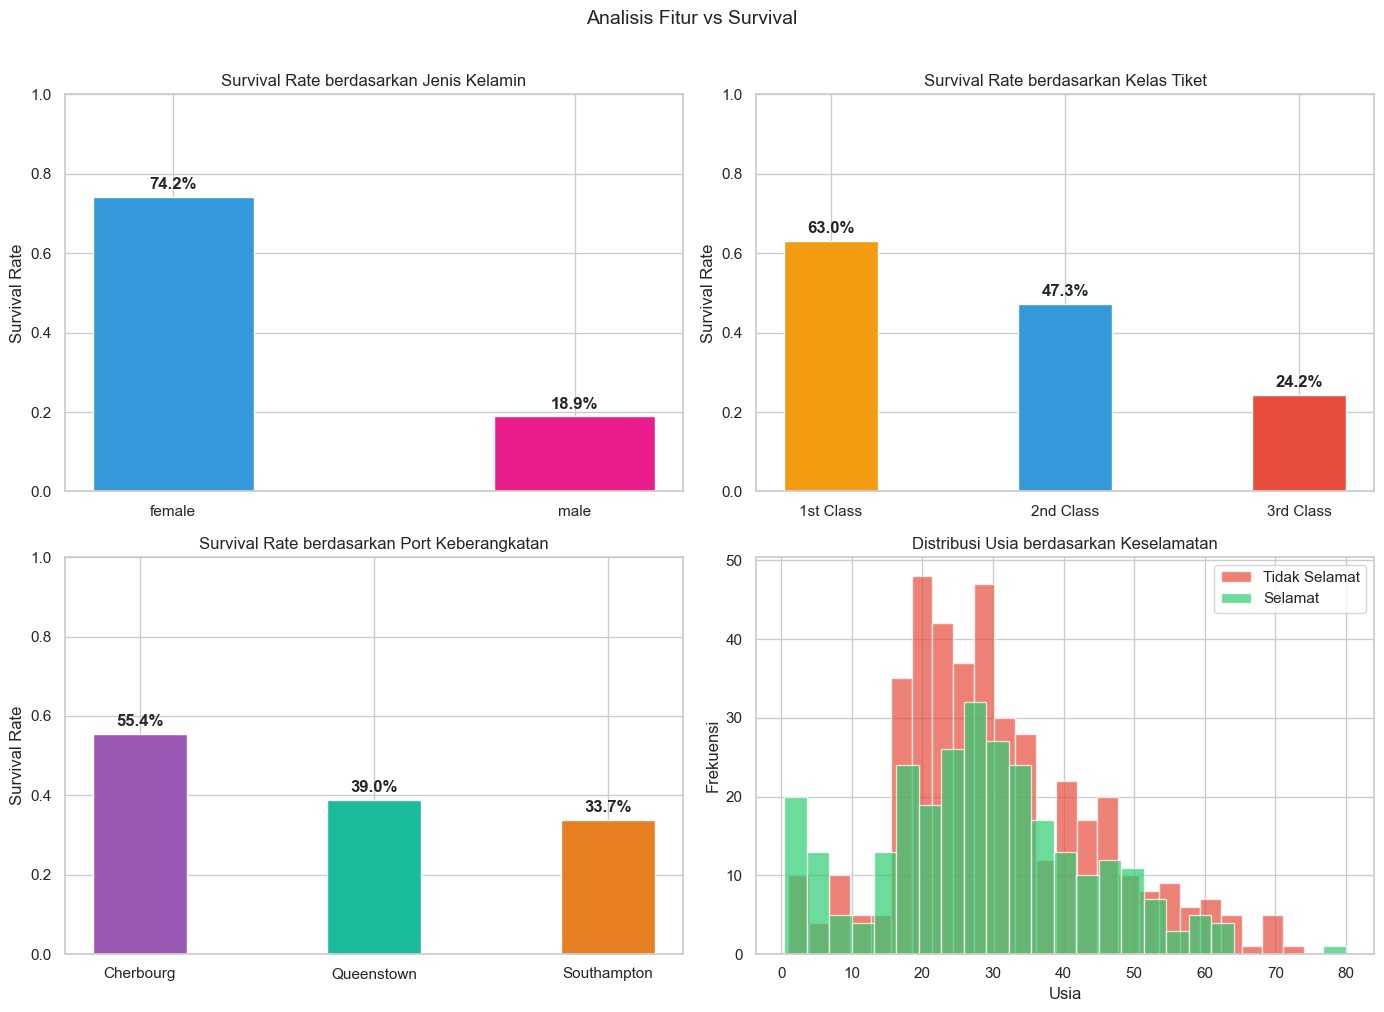

In [39]:
#Survival Rate berdasarkan fitur penting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival by Sex
sex_survival = df.groupby('Sex')['Survived'].mean()
bars = axes[0,0].bar(sex_survival.index, sex_survival.values,
                     color=['#3498db','#e91e8c'], edgecolor='white', width=0.4)
axes[0,0].set_title('Survival Rate berdasarkan Jenis Kelamin', fontsize=12)
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_ylim(0, 1)
for bar, val in zip(bars, sex_survival.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02,
                   f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')

# Survival by Pclass
pclass_survival = df.groupby('Pclass')['Survived'].mean()
colors_p = ['#f39c12', '#3498db', '#e74c3c']
bars2 = axes[0,1].bar(['1st Class','2nd Class','3rd Class'],
                       pclass_survival.values,
                       color=colors_p, edgecolor='white', width=0.4)
axes[0,1].set_title('Survival Rate berdasarkan Kelas Tiket', fontsize=12)
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_ylim(0, 1)
for bar, val in zip(bars2, pclass_survival.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02,
                   f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')

# Survival by Embarked
emb_survival = df.groupby('Embarked')['Survived'].mean().sort_values(ascending=False)
emb_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
emb_labels = [emb_map.get(k, k) for k in emb_survival.index]
bars3 = axes[1,0].bar(emb_labels, emb_survival.values,
                       color=['#9b59b6','#1abc9c','#e67e22'], edgecolor='white', width=0.4)
axes[1,0].set_title('Survival Rate berdasarkan Port Keberangkatan', fontsize=12)
axes[1,0].set_ylabel('Survival Rate')
axes[1,0].set_ylim(0, 1)
for bar, val in zip(bars3, emb_survival.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02,
                   f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')

# Distribusi Age
survived_age = df[df['Survived']==1]['Age'].dropna()
died_age = df[df['Survived']==0]['Age'].dropna()
axes[1,1].hist(died_age, bins=25, alpha=0.7, color='#e74c3c', label='Tidak Selamat', edgecolor='white')
axes[1,1].hist(survived_age, bins=25, alpha=0.7, color='#2ecc71', label='Selamat', edgecolor='white')
axes[1,1].set_title('Distribusi Usia berdasarkan Keselamatan', fontsize=12)
axes[1,1].set_xlabel('Usia')
axes[1,1].set_ylabel('Frekuensi')
axes[1,1].legend()

plt.suptitle('Analisis Fitur vs Survival', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('analisis_fitur_survival.png', dpi=150, bbox_inches='tight')
plt.show()

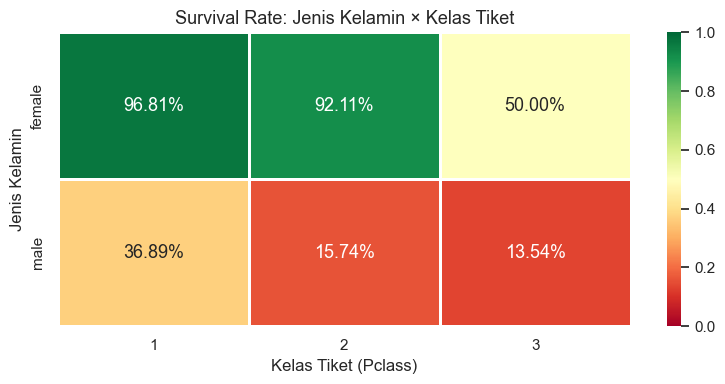


Interpretasi:
- Wanita kelas 1 dan 2 memiliki survival rate tertinggi (mendekati 100%)
- Pria kelas 3 memiliki survival rate terendah
- Pola ini sesuai dengan kebijakan "Women and Children first" saat kapal tenggelam


In [40]:
# Survival by Sex x Pclass (heatmap)
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=1, linecolor='white', annot_kws={'size': 13})
plt.title('Survival Rate: Jenis Kelamin × Kelas Tiket', fontsize=13)
plt.ylabel('Jenis Kelamin')
plt.xlabel('Kelas Tiket (Pclass)')
plt.tight_layout()
plt.savefig('heatmap_sex_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretasi:')
print('- Wanita kelas 1 dan 2 memiliki survival rate tertinggi (mendekati 100%)')
print('- Pria kelas 3 memiliki survival rate terendah')
print('- Pola ini sesuai dengan kebijakan "Women and Children first" saat kapal tenggelam')

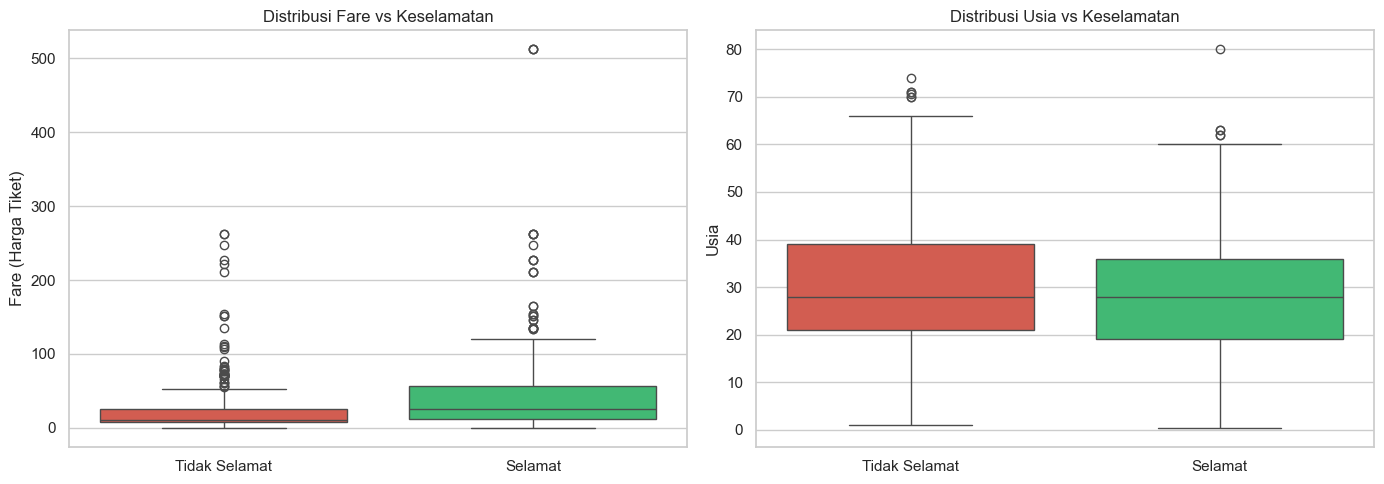

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare vs Survived
sns.boxplot(data=df, x='Survived', y='Fare',
            palette={'0': '#e74c3c', '1': '#2ecc71'}, ax=axes[0])
axes[0].set_xticklabels(['Tidak Selamat', 'Selamat'])
axes[0].set_title('Distribusi Fare vs Keselamatan', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Fare (Harga Tiket)')

# Age vs Survived
sns.boxplot(data=df, x='Survived', y='Age',
            palette={'0': '#e74c3c', '1': '#2ecc71'}, ax=axes[1])
axes[1].set_xticklabels(['Tidak Selamat', 'Selamat'])
axes[1].set_title('Distribusi Usia vs Keselamatan', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Usia')

plt.tight_layout()
plt.savefig('boxplot_fare_age.png', dpi=150, bbox_inches='tight')
plt.show()

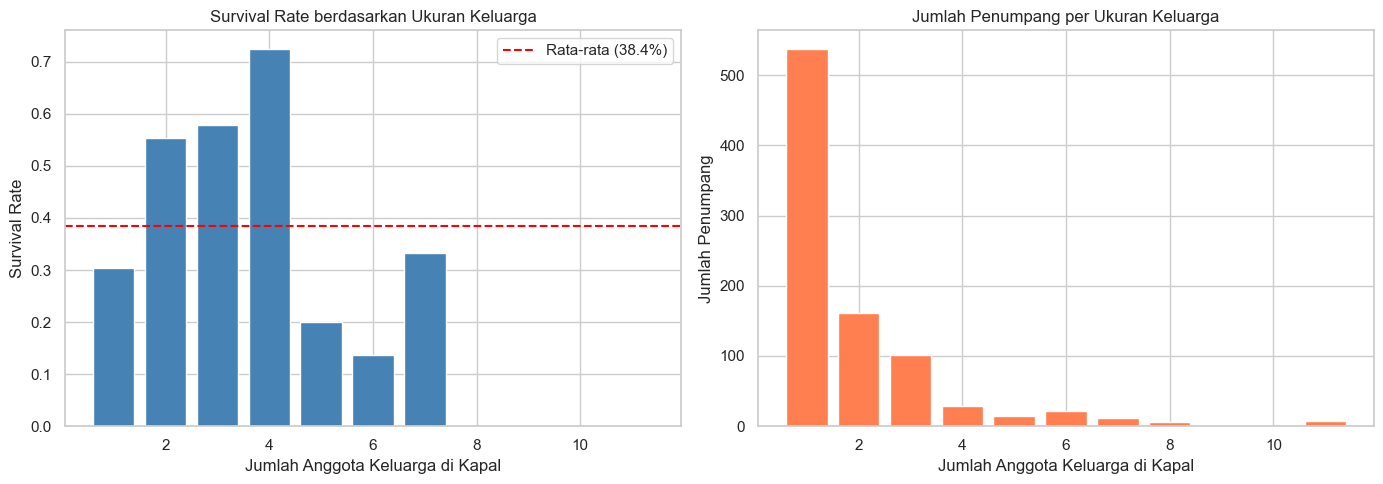

Catatan: FamilySize akan menjadi fitur baru (feature engineering)


In [41]:
# Analisis SibSp dan Parch (keluarga di kapal)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 untuk diri sendiri

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate berdasarkan ukuran keluarga
family_survival = df.groupby('FamilySize')['Survived'].mean()
family_counts = df.groupby('FamilySize').size()

axes[0].bar(family_survival.index, family_survival.values, color='steelblue', edgecolor='white')
axes[0].set_title('Survival Rate berdasarkan Ukuran Keluarga', fontsize=12)
axes[0].set_xlabel('Jumlah Anggota Keluarga di Kapal')
axes[0].set_ylabel('Survival Rate')
axes[0].axhline(y=df['Survived'].mean(), color='red', linestyle='--',
                label=f'Rata-rata ({df["Survived"].mean():.1%})')
axes[0].legend()

# Jumlah penumpang per ukuran keluarga
axes[1].bar(family_counts.index, family_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Jumlah Penumpang per Ukuran Keluarga', fontsize=12)
axes[1].set_xlabel('Jumlah Anggota Keluarga di Kapal')
axes[1].set_ylabel('Jumlah Penumpang')

plt.tight_layout()
plt.savefig('family_size_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Catatan: FamilySize akan menjadi fitur baru (feature engineering)')

=== DISTRIBUSI TITLE ===
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


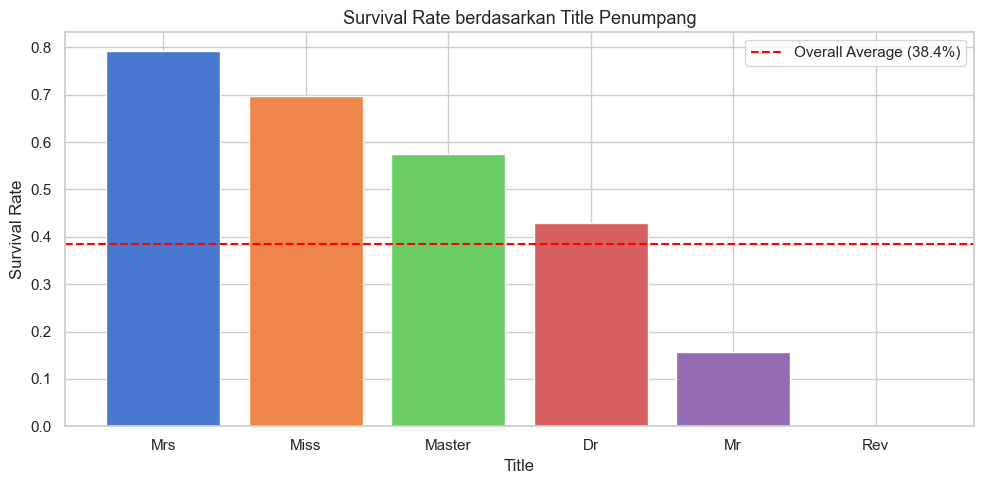

In [13]:
# 3.10 Analisis Title dari Name
df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.')
print('=== DISTRIBUSI TITLE ===')
print(df['Title'].value_counts())

# Survival rate per title
title_survival = df.groupby('Title')['Survived'].agg(['mean', 'count'])
title_survival = title_survival[title_survival['count'] >= 5].sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(title_survival.index, title_survival['mean'],
              color=sns.color_palette('muted', len(title_survival)), edgecolor='white')
ax.set_title('Survival Rate berdasarkan Title Penumpang', fontsize=13)
ax.set_xlabel('Title')
ax.set_ylabel('Survival Rate')
ax.axhline(y=df['Survived'].mean(), color='red', linestyle='--',
           label=f'Overall Average ({df["Survived"].mean():.1%})')
ax.legend()
plt.tight_layout()
plt.savefig('title_survival.png', dpi=150, bbox_inches='tight')
plt.show()

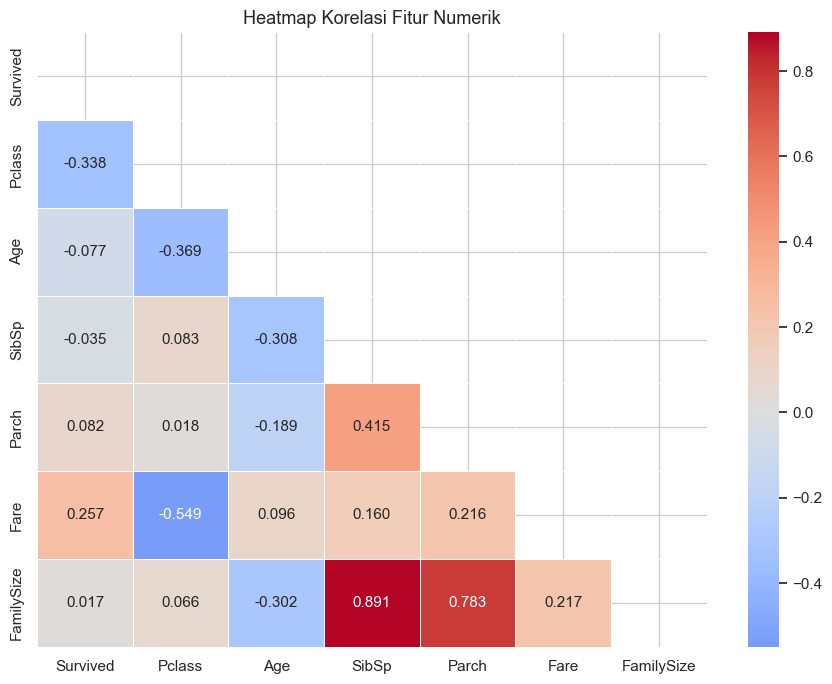


=== KORELASI DENGAN SURVIVED ===
Pclass        0.338481
Fare          0.257307
Parch         0.081629
Age           0.077221
SibSp         0.035322
FamilySize    0.016639
Name: Survived, dtype: float64


In [42]:
# Korelasi antar fitur numerik
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 11})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== KORELASI DENGAN SURVIVED ===')
print(corr['Survived'].abs().sort_values(ascending=False)[1:])

## Feature Engineering

Membuat fitur-fitur baru dari kolom yang ada untuk meningkatkan kemampuan prediktif model.

In [15]:
def feature_engineering(df):
    """Membuat fitur baru dari kolom yang ada."""
    df = df.copy()

    # 1. Title dari Name
    df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.')
    # Kelompokkan title langka menjadi 'Rare'
    common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
    df['Title'] = df['Title'].apply(
        lambda x: x.strip() if x.strip() in common_titles else 'Rare'
    )
    print(f'Title unik setelah grouping: {df["Title"].unique()}')

    # 2. FamilySize = SibSp + Parch + 1
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # 3. IsAlone: 1 jika travelling sendiri
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # 4. AgeGroup: kategorisasi usia
    df['AgeGroup'] = pd.cut(df['Age'],
                            bins=[0, 12, 18, 35, 60, 100],
                            labels=['Child','Teen','Adult','Middle','Senior'],
                            right=True)

    # 5. FareGroup: kategorisasi harga tiket
    df['FareGroup'] = pd.qcut(df['Fare'], q=4,
                               labels=['Low','Medium','High','Very High'],
                               duplicates='drop')

    # 6. HasCabin: apakah informasi kabin tersedia
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    return df

df = feature_engineering(df)
print(f'\nFitur baru ditambahkan: Title, FamilySize, IsAlone, AgeGroup, FareGroup, HasCabin')
print(f'Shape setelah feature engineering: {df.shape}')
df[['Title','FamilySize','IsAlone','AgeGroup','FareGroup','HasCabin']].head(10)

Title unik setelah grouping: ['Mr' 'Mrs' 'Miss' 'Master' 'Rare']

Fitur baru ditambahkan: Title, FamilySize, IsAlone, AgeGroup, FareGroup, HasCabin
Shape setelah feature engineering: (891, 18)


,Title,FamilySize,IsAlone,AgeGroup,FareGroup,HasCabin
0,Mr,2,0,Adult,Low,0
1,Mrs,2,0,Middle,Very High,1
2,Miss,1,1,Adult,Medium,0
3,Mrs,2,0,Adult,Very High,1
4,Mr,1,1,Adult,Medium,0
5,Mr,1,1,NaN,Medium,0
6,Mr,1,1,Middle,Very High,1
7,Master,5,0,Child,High,0
8,Mrs,3,0,Adult,Medium,0
9,Mrs,2,0,Teen,High,0


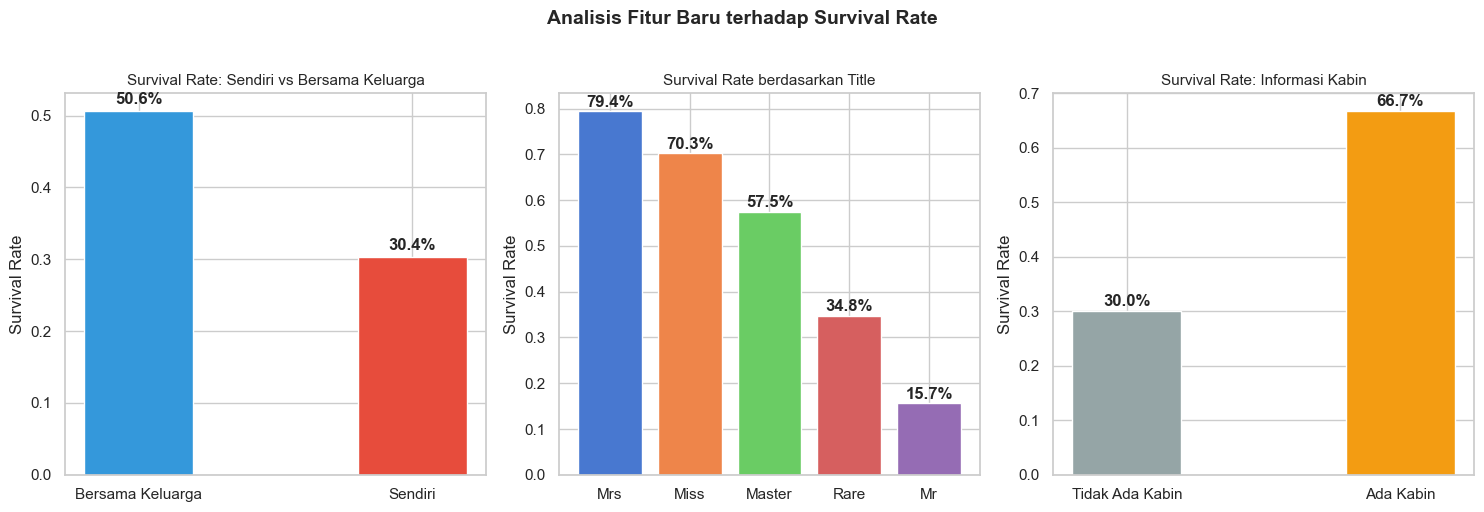

In [50]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Visualisasi fitur baru
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# IsAlone vs Survived
alone_surv = df.groupby('IsAlone')['Survived'].mean()
axes[0].bar(['Bersama Keluarga', 'Sendiri'], alone_surv.values,
            color=['#3498db','#e74c3c'], edgecolor='white', width=0.4)
axes[0].set_title('Survival Rate: Sendiri vs Bersama Keluarga', fontsize=11)
axes[0].set_ylabel('Survival Rate')
for i, v in enumerate(alone_surv.values):
    axes[0].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Title vs Survived
title_surv = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
axes[1].bar(title_surv.index, title_surv.values,
            color=sns.color_palette('muted', len(title_surv)), edgecolor='white')
axes[1].set_title('Survival Rate berdasarkan Title', fontsize=11)
axes[1].set_ylabel('Survival Rate')
for i, v in enumerate(title_surv.values):
    axes[1].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

# HasCabin vs Survived
cabin_surv = df.groupby('HasCabin')['Survived'].mean()
axes[2].bar(['Tidak Ada Kabin', 'Ada Kabin'], cabin_surv.values,
            color=['#95a5a6','#f39c12'], edgecolor='white', width=0.4)
axes[2].set_title('Survival Rate: Informasi Kabin', fontsize=11)
axes[2].set_ylabel('Survival Rate')
for i, v in enumerate(cabin_surv.values):
    axes[2].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.suptitle('Analisis Fitur Baru terhadap Survival Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fitur_baru_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [52]:
# Pemilihan fitur untuk modeling
# Di tahap ini kita pilih fitur-fitur yang mau dipakai buat model.
FEATURES_TO_DROP = ['PassengerId', 'Name', 'Ticket', 'Cabin',
                    'SibSp', 'Parch']  # SibSp & Parch sudah di-capture di FamilySize
TARGET = 'Survived'

df_proc = df.copy()
df_proc = df_proc.drop(columns=FEATURES_TO_DROP)

print(f'Kolom yang digunakan ({len(df_proc.columns)-1} fitur + 1 target):')
print([c for c in df_proc.columns if c != TARGET])

Kolom yang digunakan (9 fitur + 1 target):
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'HasCabin']


In [61]:
# Handle missing values sebelum encoding
print('=== MISSING VALUES SEBELUM IMPUTASI ===')
print(df_proc.isnull().sum()[df_proc.isnull().sum() > 0])

# Age: imputasi dengan median per Title (lebih akurat)
age_median_by_title = df_proc.groupby('Title')['Age'].transform('median')
df_proc['Age'] = df_proc['Age'].fillna(age_median_by_title)
# Fallback jika masih ada NaN
df_proc['Age'] = df_proc['Age'].fillna(df_proc['Age'].median())

# Embarked: imputasi dengan modus (Southampton = 'S')
df_proc['Embarked'] = df_proc['Embarked'].fillna(df_proc['Embarked'].mode()[0])

# Fare: imputasi dengan median (jika ada)
df_proc['Fare'] = df_proc['Fare'].fillna(df_proc['Fare'].median())

# AgeGroup & FareGroup: isi NaN dengan Unknown
if 'Unknown' not in df_proc['AgeGroup'].cat.categories:
    df_proc['AgeGroup'] = df_proc['AgeGroup'].cat.add_categories('Unknown')
df_proc['AgeGroup'] = df_proc['AgeGroup'].fillna('Unknown')

if 'Unknown' not in df_proc['FareGroup'].cat.categories:
    df_proc['FareGroup'] = df_proc['FareGroup'].cat.add_categories('Unknown')
df_proc['FareGroup'] = df_proc['FareGroup'].fillna('Unknown')

print('\n=== MISSING VALUES SETELAH IMPUTASI ===')
print(df_proc.isnull().sum()[df_proc.isnull().sum() > 0])
if df_proc.isnull().sum().sum() == 0:
    print('Semua missing values berhasil ditangani!')

=== MISSING VALUES SEBELUM IMPUTASI ===
Series([], dtype: int64)

=== MISSING VALUES SETELAH IMPUTASI ===
Series([], dtype: int64)
Semua missing values berhasil ditangani!


In [62]:
#Encode kolom kategorikal
cat_cols_to_encode = ['Sex', 'Embarked', 'Title', 'AgeGroup', 'FareGroup']
print(f'Kolom yang akan di-encode: {cat_cols_to_encode}')

label_encoders = {}
for col in cat_cols_to_encode:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, range(len(le.classes_))))}')

print(f'\nEncoding selesai. Semua kolom sekarang numerik.')
df_proc.dtypes

Kolom yang akan di-encode: ['Sex', 'Embarked', 'Title', 'AgeGroup', 'FareGroup']
  Sex: {'female': 0, 'male': 1}
  Embarked: {'C': 0, 'Q': 1, 'S': 2}
  Title: {'Master': 0, 'Miss': 1, 'Mr': 2, 'Mrs': 3, 'Rare': 4}
  AgeGroup: {'Anak': 0, 'Dewasa': 1, 'Dewasa Muda': 2, 'Lansia': 3, 'Remaja': 4}
  FareGroup: {'Mahal': 0, 'Menengah': 1, 'Murah': 2, 'Sangat Mahal': 3, 'Unknown': 4}

Encoding selesai. Semua kolom sekarang numerik.


Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
Title           int64
HasCabin        int64
AgeGroup        int64
FareGroup       int64
dtype: object

In [63]:
# Pisahkan fitur (X) dan target (y)
X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET]

print(f'Fitur (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')
print(f'Distribusi target: Selamat={y.sum()} ({y.mean():.1%}), Tidak={len(y)-y.sum()}')

Fitur (X) shape: (891, 11)
Target (y) shape: (891,)
Distribusi target: Selamat=342 (38.4%), Tidak=549


In [64]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'=== TRAIN-TEST SPLIT ===')
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train — Selamat: {y_train.sum()}, Tidak: {(y_train==0).sum()}')
print(f'y_test  — Selamat: {y_test.sum()}, Tidak: {(y_test==0).sum()}')

=== TRAIN-TEST SPLIT ===
X_train : (712, 11)
X_test  : (179, 11)
y_train — Selamat: 273, Tidak: 439
y_test  — Selamat: 69, Tidak: 110


In [65]:
# Standarisasi fitur numerik dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print('StandardScaler diterapkan (fit pada train, transform pada train+test).')
print(f'\nStatistik setelah scaling (X_train):')
print(X_train_scaled.describe().round(3).loc[['mean','std']])

StandardScaler diterapkan (fit pada train, transform pada train+test).

Statistik setelah scaling (X_train):
      Pclass    Sex    Age   Fare  Embarked  FamilySize  IsAlone  Title  \
mean  -0.000 -0.000  0.000 -0.000     0.000       0.000    0.000  0.000   
std    1.001  1.001  1.001  1.001     1.001       1.001    1.001  1.001   

      HasCabin  AgeGroup  FareGroup  
mean     0.000    -0.000     -0.000  
std      1.001     1.001      1.001  


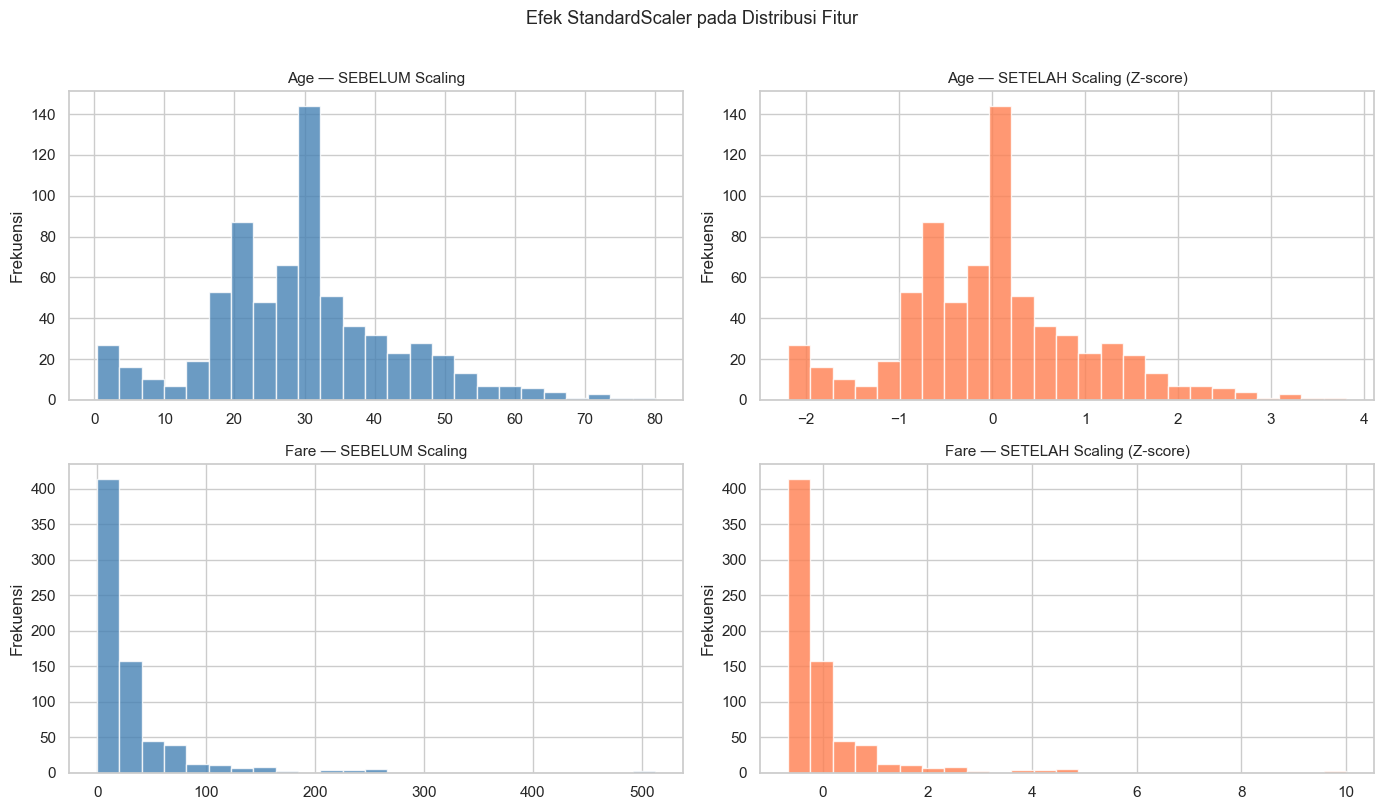

In [66]:
# Visualisasi before-after scaling untuk fitur Age dan Fare
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(['Age', 'Fare']):
    # Before
    axes[i, 0].hist(X_train[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col} — SEBELUM Scaling', fontsize=11)
    axes[i, 0].set_ylabel('Frekuensi')

    # After
    axes[i, 1].hist(X_train_scaled[col], bins=25, color='coral', edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'{col} — SETELAH Scaling (Z-score)', fontsize=11)
    axes[i, 1].set_ylabel('Frekuensi')

plt.suptitle('Efek StandardScaler pada Distribusi Fitur', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('before_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Simpan Hasil Preprocessing

In [67]:
# Gabungkan X_scaled + y → simpan ke CSV
train_final = X_train_scaled.copy()
train_final['Survived'] = y_train.values
train_final['split'] = 'train'

test_final = X_test_scaled.copy()
test_final['Survived'] = y_test.values
test_final['split'] = 'test'

all_processed = pd.concat([train_final, test_final], ignore_index=True)
all_processed.to_csv('titanic_preprocessing.csv', index=False)

print('=== FILE PREPROCESSING TERSIMPAN ===')
print(f'titanic_preprocessing.csv : {all_processed.shape}')
print(f'\nKolom dalam file preprocessing:')
print(all_processed.columns.tolist())
print(f'\nPreview 5 baris:')
all_processed.head()

=== FILE PREPROCESSING TERSIMPAN ===
titanic_preprocessing.csv : (891, 13)

Kolom dalam file preprocessing:
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'HasCabin', 'AgeGroup', 'FareGroup', 'Survived', 'split']

Preview 5 baris:


,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title,HasCabin,AgeGroup,FareGroup,Survived,split
0,0.829568,0.742427,0.036076,0.513812,0.584892,-0.556339,0.800346,0.112376,-0.538382,0.249706,-1.445435,1,train
1,-0.370945,0.742427,0.036076,-0.662563,0.584892,-0.556339,0.800346,0.112376,-0.538382,0.249706,2.860631,0,train
2,-1.571457,0.742427,0.036076,3.955399,0.584892,-0.556339,0.800346,0.112376,1.857418,0.249706,1.784115,0,train
3,0.829568,-1.346933,-0.868950,-0.467874,0.584892,0.073412,-1.249460,1.382398,-0.538382,2.444657,0.707598,1,train
4,-0.370945,-1.346933,0.111495,-0.115977,0.584892,0.703162,-1.249460,1.382398,-0.538382,0.249706,-0.368919,1,train


In [68]:
# Ringkasan akhir
print('='*55)
print('           RINGKASAN PREPROCESSING TITANIC')
print('='*55)
print(f'Dataset awal              : {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom')
print(f'Fitur yang digunakan      : {X.shape[1]} fitur')
print(f'Fitur baru (engineering)  : Title, FamilySize, IsAlone, AgeGroup, FareGroup, HasCabin')
print(f'Kolom dihapus             : PassengerId, Name, Ticket, Cabin, SibSp, Parch')
print(f'Missing values Age        : Imputasi median per Title')
print(f'Missing values Embarked   : Imputasi modus (S)')
print(f'Encoding                  : LabelEncoder (Sex, Embarked, Title, AgeGroup, FareGroup)')
print(f'Scaling                   : StandardScaler')
print(f'Train set                 : {len(train_final)} baris ({len(train_final)/len(all_processed)*100:.0f}%)')
print(f'Test set                  : {len(test_final)} baris ({len(test_final)/len(all_processed)*100:.0f}%)')
print(f'Output file               : titanic_preprocessing.csv')
print('='*55)
print('Preprocessing selesai.')

           RINGKASAN PREPROCESSING TITANIC
Dataset awal              : 891 baris x 12 kolom
Fitur yang digunakan      : 11 fitur
Fitur baru (engineering)  : Title, FamilySize, IsAlone, AgeGroup, FareGroup, HasCabin
Kolom dihapus             : PassengerId, Name, Ticket, Cabin, SibSp, Parch
Missing values Age        : Imputasi median per Title
Missing values Embarked   : Imputasi modus (S)
Encoding                  : LabelEncoder (Sex, Embarked, Title, AgeGroup, FareGroup)
Scaling                   : StandardScaler
Train set                 : 712 baris (80%)
Test set                  : 179 baris (20%)
Output file               : titanic_preprocessing.csv
Preprocessing selesai.
